## Feature Engineering


### Imports

In [1]:
from feature_engineering import merge_and_engineer_features, load_and_clean_data

In [2]:
# Step 1: Load and Clean Data
df_energy_clean, city_dfs_clean = load_and_clean_data(
    energy_path="data/energy_dataset.csv", 
    weather_path="data/weather_features.csv"
)

# Step 2: Feature Engineering
df_model = merge_and_engineer_features(df_energy_clean, city_dfs_clean)

# Step 3: Verify Results
print("\n--- SAMPLE OUTPUT ---")
cols_to_show = [
    'total load actual', 'day_type', 'is_holiday_madrid', 'is_holiday_barcelona',
    'temp_madrid', 'temp_barcelona', 'temp_madrid_lag_24', 'load_rolling_mean_24h'
]
display(df_model[cols_to_show].head())


--- 1. LOADING AND CLEANING DATA ---
Processing Energy Dataset...
Processing Weather Dataset...
Data loading and cleaning complete.

--- 2. FEATURE ENGINEERING ---
Merging individual city weather datasets...
Creating temporal variables and cyclical encoding...
Incorporating external covariates: National and Regional Holidays...
Generating safe lags for Day-Ahead prediction...
Generating safe rolling window statistics...
Dropping rows with NaNs generated by lags (first 8 days)...
✅ Process completed. Final dimensions: (34873, 100)

--- SAMPLE OUTPUT ---


,total load actual,day_type,is_holiday_madrid,is_holiday_barcelona,temp_madrid,temp_barcelona,temp_madrid_lag_24,load_rolling_mean_24h
time,,,,,,,,
2015-01-08 22:00:00+00:00,26436.0,0,0,0,-3.856,9.6,-5.0910,32105.000000
2015-01-08 23:00:00+00:00,27485.0,0,0,0,-3.856,10.4,-5.0910,31949.583333
2015-01-09 00:00:00+00:00,25750.0,0,0,0,-3.856,10.3,-5.4325,31810.500000
2015-01-09 01:00:00+00:00,24760.0,0,0,0,-3.902,10.0,-5.7740,31679.791667
2015-01-09 02:00:00+00:00,24188.0,0,0,0,-3.902,10.4,-5.7740,31546.375000


Splitting data at cutoff date: 2018-01-01 00:00:00+00:00
  Training set: 26,114 hours (2015-01-08 to 2017-12-31)
  Testing set:  8,759 hours (2018-01-01 to 2018-12-31)

Calculating official TSO baseline metrics...
🎯 OFFICIAL TSO BASELINE (2018):
   MAE:  269.85 MWh
   MAPE: 0.926 %
   RMSE: 389.32 MWh


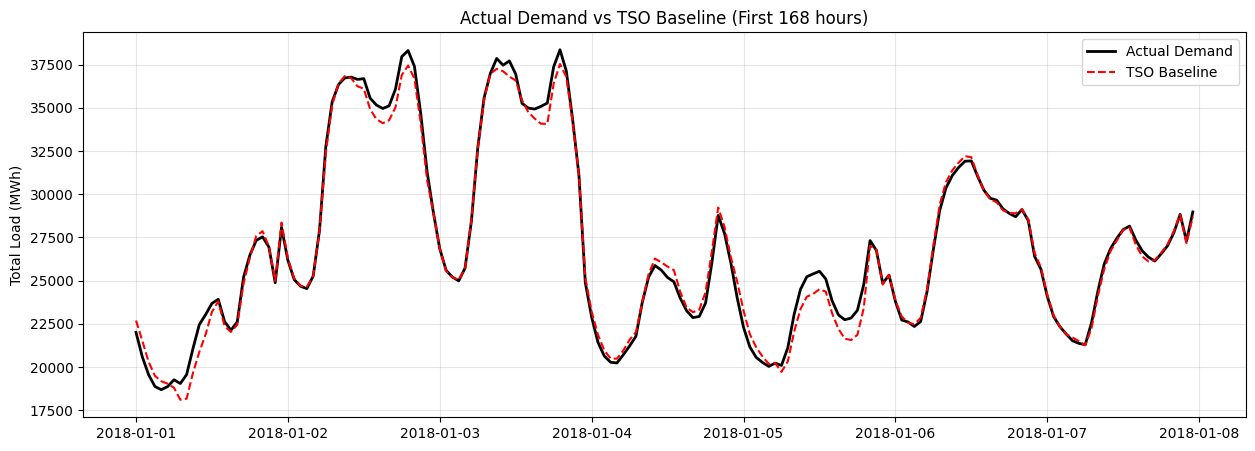

In [3]:
# Import the functions from your newly created .py file
from evaluate import temporal_train_test_split, evaluate_tso_baseline, plot_forecast_vs_actual

# 1. Split the data (assuming df_model is your fully engineered dataframe)
X_train, X_test, y_train, y_test = temporal_train_test_split(
    df=df_model, 
    target_col='total load actual', 
    cutoff_date='2018-01-01 00:00:00+00:00'
)

# 2. Get the baseline metrics to beat
tso_forecast, tso_metrics = evaluate_tso_baseline(
    y_test=y_test, 
    energy_csv_path="data/energy_dataset.csv"
)

# 3. Visualize the first week of 2018
plot_forecast_vs_actual(y_actual=y_test, y_pred=tso_forecast, model_name="TSO Baseline", window_hours=168)

In [ ]:
from Time_Series_Final_Project.modeling_ml import tune_xgboost_with_cv
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import numpy as np
best_xgb_model = tune_xgboost_with_cv(X_train, y_train)

# Now evaluate this optimized model against the official TSO baseline on the Test set
print("\n--- 5. FINAL EVALUATION ON HOLD-OUT TEST SET (2018) ---")
y_pred_tuned = best_xgb_model.predict(X_test)
final_mae = mean_absolute_error(y_test, y_pred_tuned)
final_mape = mean_absolute_percentage_error(y_test, y_pred_tuned) * 100
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
print(f"Tuned XGBoost Test MAE: {final_mae:,.2f} MWh")
print(f"Tuned XGBoost Test MAPE: {final_mape:.3f} %")
print(f"Tuned XGBoost Test RMSE: {final_rmse:,.2f} MWh")

--- 4. HYPERPARAMETER TUNING WITH TIME SERIES CV ---
Starting cross-validation search (this might take a few minutes)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Cross-Validation Complete!
Best Hyperparameters Found:
   - subsample: 0.7
   - n_estimators: 800
   - max_depth: 6
   - learning_rate: 0.1
   - colsample_bytree: 0.8

Expected Validation MAE (based on CV): 1,151.01 MWh

--- 5. FINAL EVALUATION ON HOLD-OUT TEST SET (2018) ---
Tuned XGBoost Test MAE: 1,030.50 MWh


--- 4. TRAINING LIGHTGBM WITH QUANTILE REGRESSION ---
Training Median Model (Alpha = 0.50)...
Training Lower Bound Model (Alpha = 0.10)...
Training Upper Bound Model (Alpha = 0.90)...

📊 LIGHTGBM MEDIAN FORECAST RESULTS (2018):
   MAE:  1,030.69 MWh
   MAPE: 3.575 %
   RMSE: 1,325.27 MWh

--- 5. EVALUATING PREDICTION INTERVALS ---
🎯 INTERVAL METRICS (Target Coverage: ~80%):
   PICP (Coverage): 45.46% of actual values fell inside the interval.
   MPIW (Width):    1,721.74 MWh average width of the uncertainty band.


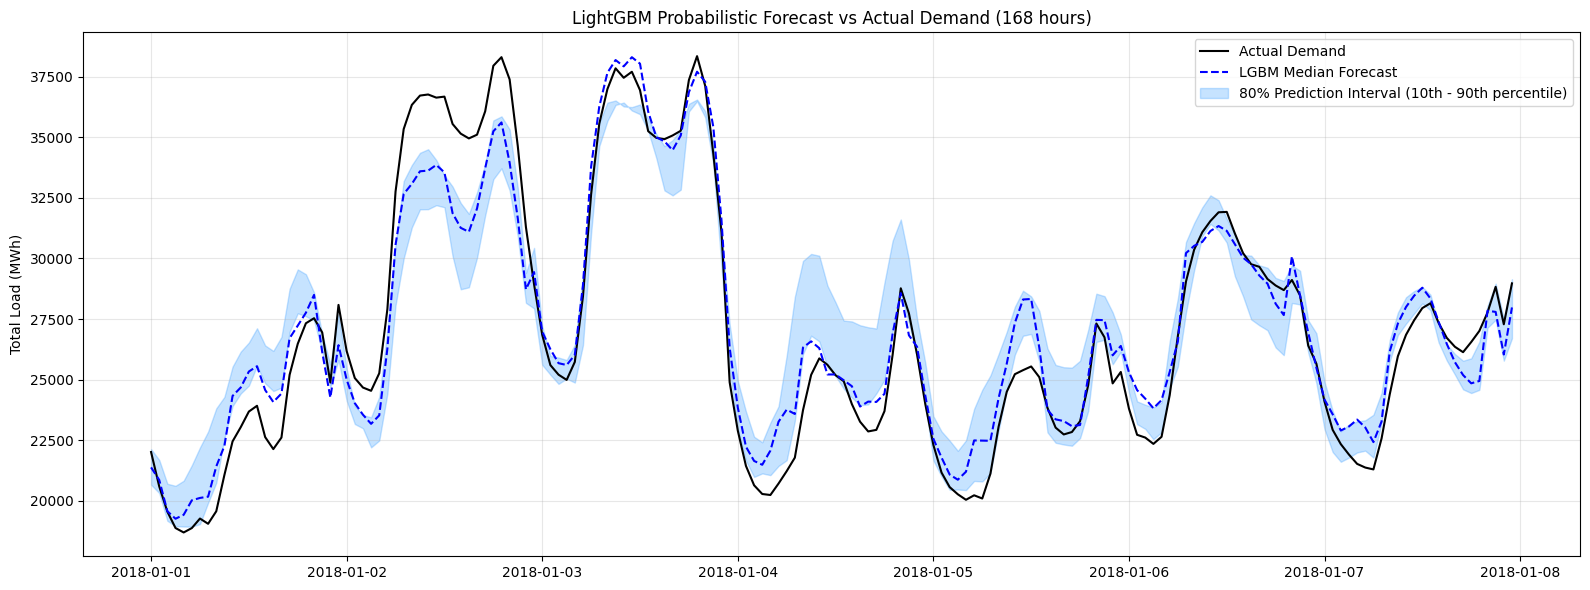

In [ ]:
# 1. Train models and get predictions
from Time_Series_Final_Project.modeling_ml import train_and_evaluate_lgbm_quantiles, evaluate_prediction_intervals, plot_lightgbm_intervals
df_quantiles, best_lgbm = train_and_evaluate_lgbm_quantiles(X_train, y_train, X_test, y_test)

# 2. Calculate interval metrics (PICP and MPIW)
picp, mpiw = evaluate_prediction_intervals(df_quantiles)

# 3. Visualize the first week with the beautiful uncertainty bands
plot_lightgbm_intervals(df_quantiles, window_hours=168, start_idx=0)


--- 5. TRAINING META PROPHET (ADDITIVE MODEL) ---
Formatting data for Prophet (ds, y)...
Initializing model and adding external regressors...
Fitting Prophet model (this may take a minute or two on hourly data)...


17:44:03 - cmdstanpy - INFO - Chain [1] start processing
17:44:33 - cmdstanpy - INFO - Chain [1] done processing


Making predictions on the 2018 Test Set...

📊 PROPHET MODEL RESULTS (TEST SET 2018):
---------------------------------------------
   MAE:  973.07 MWh
   MAPE: 3.360 %
   RMSE: 1,249.56 MWh
   PICP: 89.44% (Target: 80% coverage)


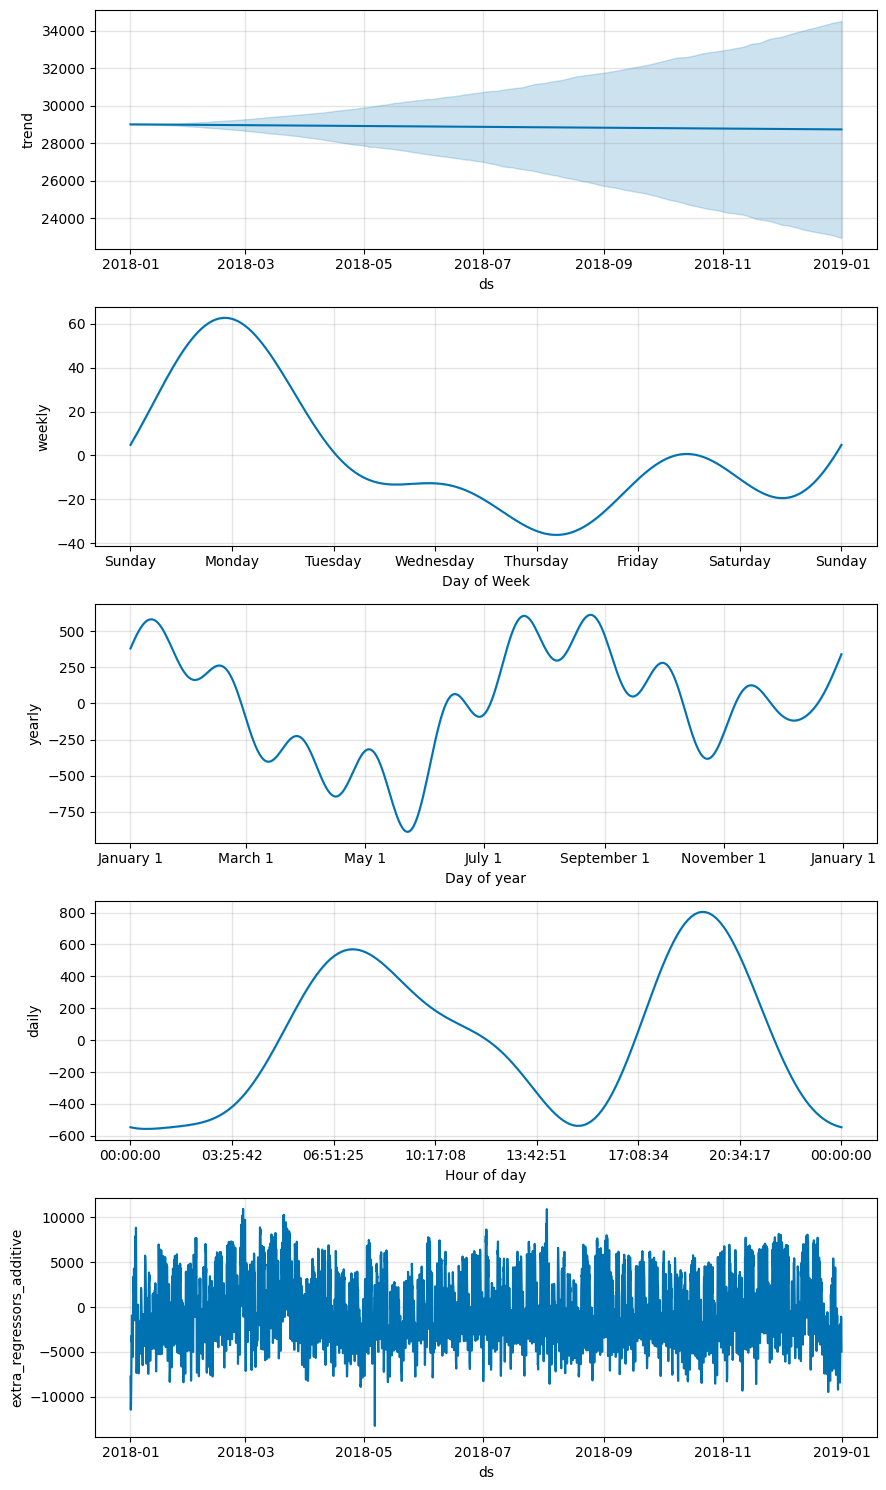

In [ ]:
from Time_Series_Final_Project.modeling_ml import train_and_evaluate_prophet
import matplotlib.pyplot as plt
model_prophet, prophet_forecast = train_and_evaluate_prophet(X_train, y_train, X_test, y_test)

# BONUS: Prophet has amazing built-in plotting for its components
# This plot breaks down the Trend vs Weekly vs Daily vs Regressors effect
# (SAVE THIS IMAGE FOR YOUR REPORT!)
fig_comp = model_prophet.plot_components(prophet_forecast)
plt.show()

In [ ]:
from Time_Series_Final_Project.modeling_ml import train_alternative_models
pred_cat, pred_mlp, pred_rf = train_alternative_models(X_train, y_train, X_test, y_test)

--- 4. TRAINING ALTERNATIVE MODELS ---
Scaling features...

Training Model A: CatBoost...
Training Model B: Neural Network (MLPRegressor)...
Training Model C: Random Forest...

📊 ALTERNATIVE MODELS COMPARISON (TEST SET 2018):
Metric     | TSO (Goal)   | CatBoost     | Neural Net   | RandomForest
---------------------------------------------------------------------------
MAE (MWh)  | 269.85       | 980.24       | 1197.22      | 1233.32     
MAPE (%)   | 0.926        | 3.420        | 4.204        | 4.236       
RMSE (MWh) | 389.32       | 1245.11      | 1505.40      | 1646.08     


In [7]:
from modeling_dl import prepare_darts_from_split, train_and_evaluate_deep_learning_fleet
darts_dataset = prepare_darts_from_split(X_train, y_train, X_test, y_test)

# Step 2: Train all models and evaluate. 
# You can change epochs=5 to epochs=15 when you want to run the final heavy test.
predictions, leaderboard = train_and_evaluate_deep_learning_fleet(
    darts_dataset, 
    lookback_hours=168, 
    horizon=24, 
    epochs=5
)

# Step 3: Visualizing the ultimate winner
top_1_name = leaderboard[0][0]
print(f"\n🎉 Visualization: Plotting the winning model ({top_1_name}) vs Actual Demand...")

plt.figure(figsize=(16, 6))
actuals_ts = darts_dataset['test_target_unscaled']

# Plotting the first 168 hours (First week of 2018)
actuals_ts[:168].plot(label='Actual Demand', color='black', linewidth=2)
predictions[top_1_name][:168].plot(label=f'{top_1_name} Forecast', color='red', linestyle='--')

plt.title(f"State-of-the-Art Deep Learning: {top_1_name} vs Actual Demand (First Week 2018)")
plt.ylabel("Total Load (MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


--- 1. PREPARING DARTS DATA FROM EXISTING TRAIN/TEST SPLIT ---
Identified Future Covariates: 11 columns
Identified Past Covariates: 88 columns
Scaling TimeSeries data...


ValueError: The model does not support `past_covariates`. It only supports `future_covariates`.


✅ Darts Data Preparation Complete.

🚀 LAUNCHING DEEP LEARNING FLEET (6 MODELS)

--- 🧠 TRAINING LSTM ---


ValueError: The model does not support `past_covariates`. It only supports `future_covariates`.